# Imports

In [14]:
!pip install htrc-feature-reader
!pip install stopwordsiso
!pip install fasttext

In [15]:
import requests
import json 
import pandas as pd
import string
from collections import Counter
from htrc_features import Volume
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import stopwordsiso as stopwords
from htrc_features import Volume

In [16]:
stop = ['af','ar', 'hy','eu','bn','br','bg','ca','cs','zh','da','de','nl','el','en','eo','et','fa','fi','fr','ga','gl','gu','ha','he','hi','hr','hu','id','it','ja','ko','ku','la','lv','lt','mr','ms','no','pl','pt','ro','ru','sk','sl','so','st','es','sw','sv','tl','th','tr','uk','ur','vi','yo','zu']
hathi =['afr', 'ara', 'arm', 'baq', 'ben', 'bre', 'bul', 'cat', 'cze','chi','dan','ger','dut','gre','eng','-esp','est','per','fin','fre','-iri','-gag','guj','hau','heb','hin','hrv', 'hun','ind','ita','jpn','kor','kur','lat','lav','lit','mar','may','nor','pol','por','rum','rus','slo','slv','som','-sso','spa','swa','swe','tgl','tha','tur','ukr','urd','vie','yor','zul']


# Import Worksets

In [21]:
workset = requests.get("https://worksets.hathitrust.org/wsid/3b7d1e60-323f-11f1-806f-2d821d8659ab")

workset_content = workset.content
data = json.loads(workset_content)

data = data['gathers']

readable_json = json.dumps(data, indent=4) # Indent with 4 spaces
print(readable_json)



[
    {
        "id": "http://hdl.handle.net/2027/hvd.32044107165342"
    },
    {
        "id": "http://hdl.handle.net/2027/hvd.hxnwyv"
    }
]


In [22]:
x = readable_json.split()
y = "http://hdl.handle.net/2027/"
volumes_en = []
for i in x:
    if y in i:
        z = i.replace(y,"")
        z = z.replace('"',"")
        volumes_en.append(z)

print (volumes_en)

['hvd.32044107165342', 'hvd.hxnwyv']


In [23]:
counter_test = Counter()
for i in volumes_en:
    try: 
        vol_test = Volume(i, download=True)
    except Exception as e:
        continue

for page in vol_test.pages():
    for word in page.tokens():
        counter_test.update(page.tokens())   

ERROR:root:HTTP Error accessing http://data.analytics.hathitrust.org/features-2020.03/hvd/hw/hvd.hxnwyv.json.bz2
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/htrc_features/caching.py", line 73, in open
    fout = super().open(id, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/htrc_features/resolvers.py", line 121, in open
    uncompressed = self._open(id = id, suffix = suffix, mode = mode, format = format,
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/htrc_features/resolvers.py", line 203, in _open
    return Path(dir, filename).open(mode = mode)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/pathlib.py", line 1013, in open
    return io.open(self, mode, buffering, encoding, errors, newline)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Fil

In [24]:
df_english = pd.DataFrame({'count': counter_test})
df_english = df_english.reset_index()
df_english = df_english.rename(columns={'index': 'word'})
df_english = df_english.sort_values(by='count',ascending=False)
df_english.head(10)

,word,count
179,Falls,519
287,Narragansett,519
262,determination,519
75,is,519
265,shale,519
134,layer,519
70,In,519
67,a,519
269,of,519
64,occur,519


# Import Stopwords

In [ ]:
vol_test_1 = Volume(volumes_rus[1])
workset_1_lan = vol_test.language
index = hathi.index(workset_1_lan)
stopword_lan_1 = stop[index]
stopwords_1 = stopwords.stopwords(stopword_lan_1)

In [26]:
stop_en = requests.get('https://data.analytics.hathitrust.org/data/text/default_stopwords_en.txt')
stop_en = stop_en.text
stop_en = stop_en.split()


In [27]:
stop_rus = requests.get('https://raw.githubusercontent.com/hingston/russian/refs/heads/master/10000-russian-words-cyrillic-only.txt')
stop_rus = stop_rus.text
stop_rus = stop_rus.split()

# Upload/Clean Volumes

In [28]:
vol_en = Volume('mdp.39015010753476', download=True)

counter_en = Counter()

for page in vol_en.pages():
    for word in page.tokens():
            counter_en.update(page.tokens())  

In [29]:
df_english = pd.DataFrame({'count': counter_en})
df_english = df_english.reset_index()
df_english = df_english.rename(columns={'index': 'word'})
df_english = df_english.sort_values(by='count', ascending=False)
df_english = df_english[~df_english['word'].isin(x)]
df_english = df_english[~df_english['word'].isin(stop.title() for stop in x)]
df_english = df_english[~df_english['word'].isin(list(string.punctuation))]
df_english = df_english[~df_english['word'].isin(["'s","''","-RRB-","-LRB-","``","--","p."])]

In [30]:
df_english.head(50)

,word,count
18,of,80111
196,and,79271
64,in,77789
210,to,77502
75,the,77318
99,a,73990
78,for,73408
226,nuclear,71961
232,that,67953
179,on,59226


In [31]:
vol_rus = Volume('mdp.39015011239624', download=True)

counter_rus = Counter()

for page in vol_rus.pages():
    for word in page.tokens():
            counter_rus.update(page.tokens())  

In [32]:
df_russian = pd.DataFrame({'count': counter_rus})
df_russian = df_russian.reset_index()
df_russian = df_russian.rename(columns={'index': 'word'})
df_russian = df_russian.sort_values(by='count', ascending=False)
df_russian = df_russian[~df_russian['word'].isin(stop_rus)]
df_russian = df_russian[~df_russian['word'].isin(stop.title() for stop in stop_rus)]
df_russian = df_russian[~df_russian['word'].isin(list(string.punctuation))]
df_russian = df_russian[~df_russian['word'].isin(["«","»", "—","»,","».", '".', '»".'])]

In [33]:
df_russian.head(50)

,word,count
145,США,48027
87,стран,37060
75,Западной,29156
315,страны,24291
382,Европы,23072
1211,года,20306
1341,американской,19665
473,западноевропейских,19558
324,политики,18569
489,Европе,17405


# Translation

In [34]:
import fasttext

# Word Clouds

In [ ]:
eng = ' '.join(df_english['word'].astype(str).tolist())

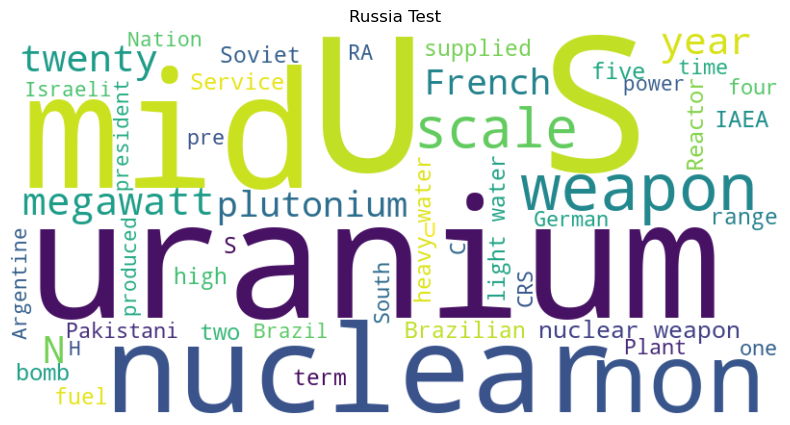

In [ ]:
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=50).generate(eng)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title("Russia Test")
plt.show()

In [ ]:
rus = ' '.join(df_russian['word'].astype(str).tolist())

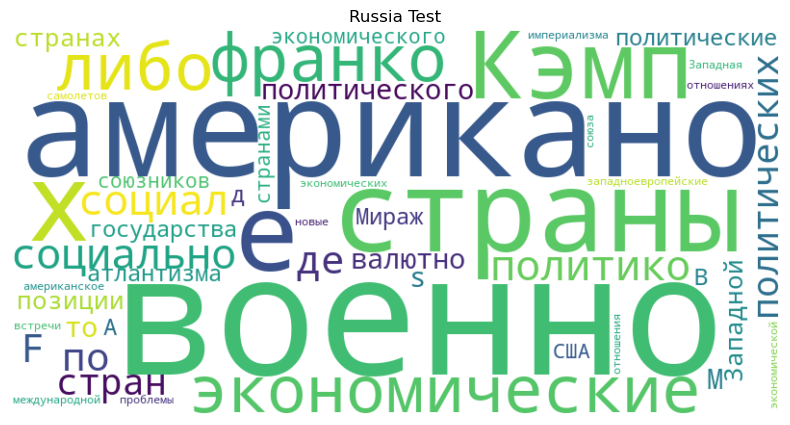

In [ ]:
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=50).generate(rus)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  
plt.title("Russia Test")
plt.show()

# Multivolumes

In [ ]:
counter_test = Counter()
for i in volumes_en:
    vol_test = Volume(i, download=True)
    for page in vol_test.pages():
        for word in page.tokens():
            counter_test.update(page.tokens())  

In [ ]:
test = pd.DataFrame({'count': counter_test})
test = test.reset_index()
test = test.rename(columns={'index': 'word'})
test = test.sort_values(by='count', ascending=False)
test = test[~test['word'].isin(stop_en)]
test = test[~test['word'].isin(stop.title() for stop in stop_en)]
test = test[~test['word'].isin(list(string.punctuation))]
test = test[~test['word'].isin(["'s","''","-RRB-","-LRB-","``","--","p."])]
test.head()

,word,count
15089,nuclear,72131
98,и,52058
144,в,51837
26,«,50143
159,на,49838


# Frequency Frequency Graph

In [ ]:
# Sample Data Structure

df_compare = pd.merge (df_english.head(50), df_russian.head(50), how ='outer', left_on='word', right_on='word')
df_compare = df_compare.fillna(0)
df_compare = df_compare.rename(columns={'count_x': 'count_en', 'count_y':'count_rus'})
df_compare['count_en'] += 1
df_compare['count_rus'] += 1
df_compare['ratio'] = np.log2(df_compare['count_en'] / df_compare['count_rus'])
df_compare


,word,count_en,count_rus,ratio
0,1980,17889.0,1.0,-14.126785
1,1981,22195.0,1.0,-14.437947
2,1982,18438.0,1.0,-14.170395
3,1983,22964.0,1.0,-14.487086
4,1984,19289.0,1.0,-14.235491
...,...,...,...,...
95,экспорта,1.0,11102.0,13.438532
96,этих,1.0,11314.0,13.465821
97,этого,1.0,12072.0,13.559377
98,этой,1.0,14115.0,13.784942


In [ ]:
fig = px.scatter(
    df_compare, 
    x="count_rus", 
    y="count_en",
    text="word",
    color="ratio",
    log_x=True, 
    log_y=True,
    color_continuous_scale='RdBu_r', 
    color_continuous_midpoint=0,     
    labels={
        "count_rus": "Occurrences in Russian Texts",
        "count_en": "Occurrences in English Texts"
    },
    title="Stop Words in English and Russian Texts"
)

# Styling to match the screenshot
fig.update_traces(textposition='top center')
fig.update_layout(
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='lightgrey'),
    yaxis=dict(showgrid=True, gridcolor='lightgrey'),
)

fig.show()

In [ ]:
volumes_rus = ['uc1.31205015914912', 'mdp.39015011239624']


counter_test = Counter()
for i in volumes_rus:
    try: 
        vol_test = Volume(i, download=True)
    except Exception as e:
        continue

for page in vol_test.pages():
    for word in page.tokens():
        counter_test.update(page.tokens())  

ERROR:root:HTTP Error accessing http://data.analytics.hathitrust.org/features-2020.03/uc1/30111/uc1.31205015914912.json.bz2
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/htrc_features/caching.py", line 73, in open
    fout = super().open(id, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/htrc_features/resolvers.py", line 121, in open
    uncompressed = self._open(id = id, suffix = suffix, mode = mode, format = format,
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/site-packages/htrc_features/resolvers.py", line 203, in _open
    return Path(dir, filename).open(mode = mode)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.12/pathlib.py", line 1013, in open
    return io.open(self, mode, buffering, encoding, errors, newline)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

In [ ]:
df_russian = pd.DataFrame({'count': counter_test})
df_russian = df_russian.reset_index()
df_russian = df_russian.rename(columns={'index': 'word'})
df_russian = df_russian.sort_values(by='count', ascending=False)
df_russian = df_russian[~df_russian['word'].isin(stop_rus)]
df_russian = df_russian[~df_russian['word'].isin(stop.title() for stop in stop_rus)]
df_russian = df_russian[~df_russian['word'].isin(list(string.punctuation))]
df_russian = df_russian[~df_russian['word'].isin(["«","»", "—","»,","».", '".', '»".'])]

In [ ]:
df_russian

,word,count
136,США,48027
203,стран,37060
143,Западной,29156
235,страны,24291
264,Европы,23072
...,...,...
15614,ПОДХОДА,15
15716,01123,4
15717,9624,4
15715,9015,4
